# 01 · Etiquetado de regímenes

Ajusta un HMM gaussiano **solo con el tramo de entrenamiento**, ordena los estados
de calma a crisis y deja la etiqueta que los cuadernos 03 y 12 tienen que predecir.

**Entradas:** `data/processed/canales.parquet` · `data/raw/precios.parquet`

**Salidas:** `data/processed/regimenes.parquet` ·
`data/processed/etiquetador_regimenes.pkl` · 2 figuras · 2 tablas en `results/metricas/`

**Tiempo:** ~1 min en CPU (dos ajustes de Baum-Welch × 5 semillas).

In [1]:
import sys; sys.path.insert(0, "..")   # permite ejecutar desde notebooks/
import src                              # fija el backend de Keras a PyTorch
from src import config, viz
config.fijar_semillas()
viz.aplicar_estilo()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import datos, evaluacion, regimenes

config.cargar_catalogo.cache_clear()

## 1 · Qué se etiqueta, y con qué tramo

No existe una etiqueta verdadera de régimen: es una variable latente. El HMM la
estima imponiendo **persistencia**, que es justo lo que distingue un régimen de
una racha de días nerviosos. Un clustering sin memoria parpadea.

Tres objetos que se confunden con facilidad y aquí se tratan distinto:

| objeto | ¿puede mirar al futuro? | por qué |
|---|---|---|
| los canales de `X` | **nunca** | son la entrada; leer el futuro sería hacer trampa |
| la etiqueta `regimen_futuro` | **sí, por definición** | es exactamente lo que se quiere predecir |
| los **parámetros** del HMM | nunca | ajustarlos con test filtraría el test a las etiquetas |

Por eso el HMM se ajusta solo hasta 2018 y después se aplica congelado: en 2018
nadie había visto el COVID ni 2022.

In [3]:
canales = pd.read_parquet(src.DIR_PROCESADO / "canales.parquet")
precios = datos.cargar_precios()
particiones = config.particiones()

catalogo = config.cargar_catalogo()["regimenes"]
etiquetado = canales[catalogo["features_etiquetado"]]
train = etiquetado.loc[:particiones.train_hasta]

print("Features de etiquetado:", ", ".join(etiquetado.columns))
print("Ajuste:", train.index[0].date(), "a", train.index[-1].date(), "·", len(train), "de", len(etiquetado), "sesiones")
print("Estados:", catalogo["n_estados"], "· covarianza", catalogo["covarianza"], "· semillas", catalogo["semillas"])

Features de etiquetado: ret_sp500, vol_realizada_z, vix_nivel_z
Ajuste: 2004-02-02 a 2018-12-31 · 3755 de 5670 sesiones
Estados: 3 · covarianza full · semillas [42, 43, 44, 45, 46]


## 2 · El control que hay que superar antes de generar nada

El HMM converge siempre. Que converja no dice nada sobre si lo que ha encontrado
son regímenes de mercado o una partición cualquiera. Antes de entrenar un solo
generador hay que comprobar dos cosas, y las dos son bloqueantes:

| control | criterio | por qué ese número |
|---|---|---|
| las bandas de crisis caen sobre 2008, 2020 y 2022 | ≥ 50 % de los días de cada episodio | son las tres crisis que nadie discute; si el modelo no las marca, no mide estrés |
| la clase de crisis no es residual ni mayoritaria | entre el 3 % y el 20 % | por debajo del 3 % no hay con qué entrenar; por encima del 20 % el estado extremo ya no separa crisis de corrección y el taller se queda sin motivo |

Empezamos por el conjunto de cinco features con el que arrancó el proyecto.
**Suspende.**

In [4]:
originales = list(etiquetado.columns) + catalogo["features_descartadas"]

rechazado = regimenes.EtiquetadorRegimenes.desde_catalogo()
rechazado.fit(canales[originales].loc[:particiones.train_hasta])
regimen_rechazado = rechazado.predict(canales[originales])
futuro_rechazado = regimenes.regimen_dominante(regimen_rechazado, config.ventanas().horizonte)

print("Conjunto original, cinco features:", ", ".join(originales))
print("Sesiones de 2021 etiquetadas como crisis:",
      round(100 * (regimen_rechazado.loc["2021"] == rechazado.estado_crisis).mean()),
      "% · ese año el S&P 500 subió un 26,9 % con volatilidad del 13 %")
control_rechazado = regimenes.control_bloqueante(regimen_rechazado, futuro_rechazado, rechazado.n_estados)
control_rechazado

Conjunto original, cinco features: ret_sp500, vol_realizada_z, vix_nivel_z, drawdown_sp500, spread_credito_z
Sesiones de 2021 etiquetadas como crisis: 40 % · ese año el S&P 500 subió un 26,9 % con volatilidad del 13 %


,medido,criterio,ok
control,,,
cubre GFC 2008,100.0,50 % o mas,True
cubre COVID 2020,96.0,50 % o mas,True
cubre Inflación 2022,44.0,50 % o mas,False
peso de la clase de crisis,19.0,entre 3 % y 20 %,True


## 3 · Las dos features que lo rompen

Un HMM gaussiano supone que dentro de cada estado las observaciones son normales
y estacionarias. Dos de las cinco rompen ese supuesto, cada una a su manera:

| feature | patología | qué se mide |
|---|---|---|
| `spread_credito_z` | **deriva** — el z-score expanding no vuelve nunca de 2008 y desde 2013 vive pegado a su techo | salto de la media entre las dos mitades de la muestra, en sigmas |
| `drawdown_sp500` | **saturación** — está acotado por cero y casi la mitad de los días vale prácticamente cero | % de sesiones en el 5 % superior de su recorrido |

Con ellas dentro, el estado extremo deja de significar "mercado en tensión" y pasa
a significar "estamos en la segunda mitad de la muestra". Y el ajuste se vuelve
**multimodal**: Baum-Welch encuentra varios óptimos locales de verosimilitud
parecida que dan etiquetados muy distintos, así que el veredicto depende de la
semilla y hasta de un cambio de dos sesiones en el panel. Eso, por sí solo, ya
descalifica al conjunto: una variable objetivo no puede cambiar de significado
según cómo se inicialice el ajuste.

In [5]:
print("Deriva: salto de la media entre las dos mitades de la muestra, en sigmas.")
print("Saturación: % de sesiones en el 5 % superior del recorrido de la feature.")
regimenes.diagnostico_features(canales[originales])

Deriva: salto de la media entre las dos mitades de la muestra, en sigmas.
Saturación: % de sesiones en el 5 % superior del recorrido de la feature.


,deriva,saturacion,apta
ret_sp500,0.02,0.0,True
vol_realizada_z,0.13,0.1,True
vix_nivel_z,0.07,0.1,True
drawdown_sp500,0.65,47.4,False
spread_credito_z,1.17,21.5,False


## 4 · El etiquetado que sí pasa

Se retiran las dos y se repite el ajuste con las tres que quedan. No se toca nada
más: mismos tres estados, misma covarianza `full`, mismas cinco semillas.

El cambio arregla las dos cosas a la vez: el control pasa, y el ajuste deja de
depender de la inicialización: las cinco semillas del catálogo
(`semillas: [42, 43, 44, 45, 46]`) convergen a la misma solución.

**La figura es el control.** Arriba lo que se descarta, abajo lo que se acepta;
las barras negras marcan dónde deberían caer las bandas oscuras. Los títulos
llevan la cifra medida en esta ejecución, no una escrita a mano.

Log-verosimilitud en train: 9418.7 · iteraciones del EM: 163
                            medido          criterio    ok
control                                                   
cubre GFC 2008               100.0        50 % o mas  True
cubre COVID 2020              96.0        50 % o mas  True
cubre Inflación 2022          56.5        50 % o mas  True
peso de la clase de crisis    15.8  entre 3 % y 20 %  True


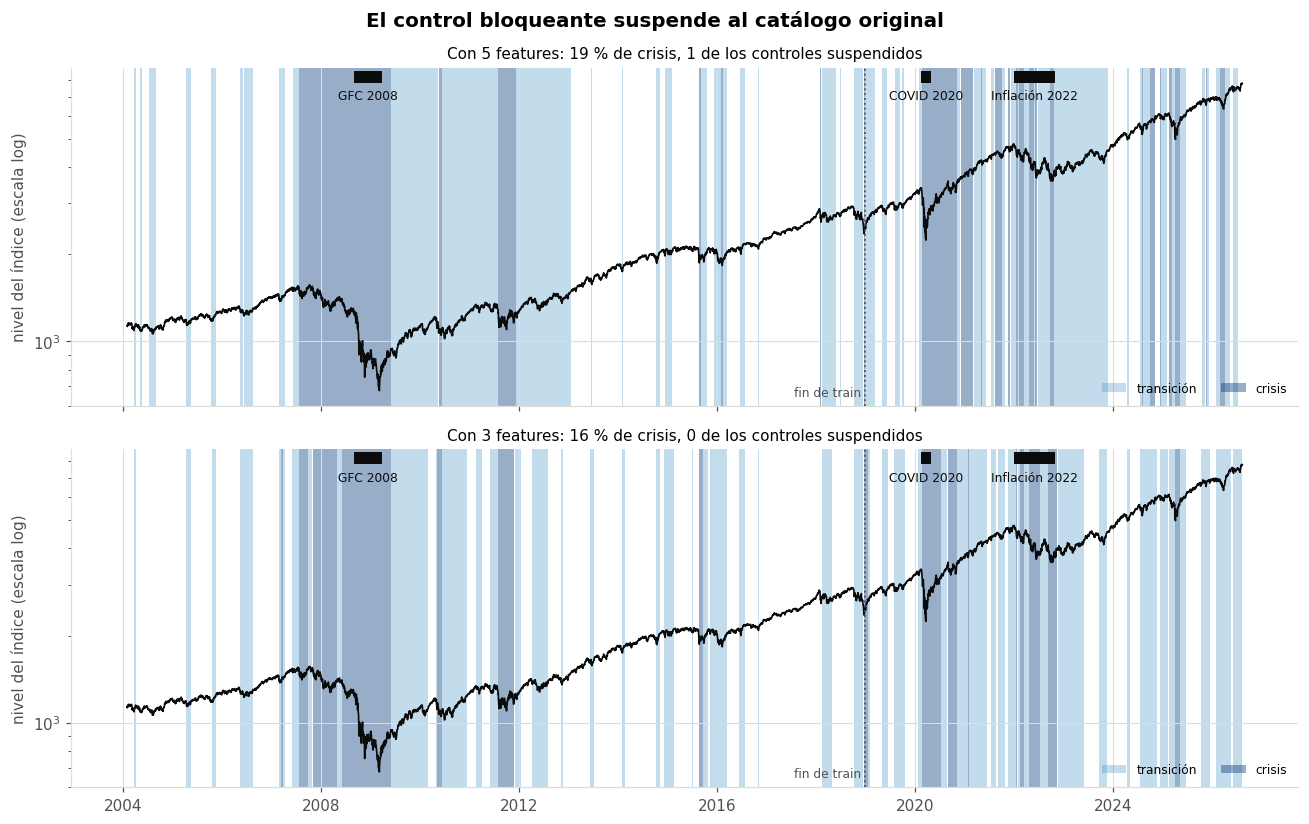

In [6]:
etiquetador = regimenes.EtiquetadorRegimenes.desde_catalogo()
etiquetador.fit(train)
regimen = etiquetador.predict(etiquetado)
proba = etiquetador.predict_proba(etiquetado)
regimen_futuro = regimenes.regimen_dominante(regimen, config.ventanas().horizonte)

control = regimenes.control_bloqueante(regimen, regimen_futuro, etiquetador.n_estados)
print("Log-verosimilitud en train:", round(etiquetador.modelo.score(train.to_numpy()), 1),
      "· iteraciones del EM:", etiquetador.modelo.monitor_.iter)
print(control.to_string())
assert control["ok"].all(), "Control bloqueante suspendido: no sigas al cuaderno 02."

indice = precios["sp500"].reindex(regimen.index)
fig, ejes = plt.subplots(2, 1, figsize=(12, 7.6), sharex=True)
titulo = "Con {} features: {} de crisis, {} de los controles suspendidos".format
viz.serie_regimenes(indice, regimen_rechazado,
                    titulo(len(originales), "{:.0f} %".format(control_rechazado.loc["peso de la clase de crisis", "medido"]), int((~control_rechazado["ok"]).sum())),
                    episodios=regimenes.EPISODIOS_REFERENCIA, corte=particiones.train_hasta, eje=ejes[0])
viz.serie_regimenes(indice, regimen,
                    titulo(len(etiquetado.columns), "{:.0f} %".format(control.loc["peso de la clase de crisis", "medido"]), 0),
                    episodios=regimenes.EPISODIOS_REFERENCIA, corte=particiones.train_hasta, eje=ejes[1])
fig.suptitle("El control bloqueante suspende al catálogo original", fontsize=13, fontweight="bold")
viz.guardar(fig, "control_etiquetado")

## 5 · Qué son los tres estados

La numeración no la elige el HMM —Baum-Welch nombra los estados en el orden en que
los encuentra— sino la canonicalización: se ordenan por volatilidad creciente, y el
retorno medio solo desempata entre estados de volatilidad parecida. Sin eso, el
estado 2 sería crisis en una ejecución y calma en la siguiente.

Las dos tablas comprueban que la numeración significa lo que dice. En el perfil la
volatilidad crece de forma monótona y **solo el estado 2 pierde dinero**;
`drawdown_sp500`, que se ha retirado del ajuste, confirma el orden desde fuera. En
la matriz de transición la diagonal pasa de 0,97: los regímenes duran meses, no
días. De ahí sale la línea base del apartado siguiente.

In [7]:
nombres = evaluacion.nombres_regimenes(etiquetador.n_estados)
retorno = canales["ret_sp500"]
estados = range(etiquetador.n_estados)

perfil = pd.DataFrame({
    "sesiones": [int((regimen == k).sum()) for k in estados],
    "ret. anualizado": [retorno[regimen == k].mean() * 252 for k in estados],
    "vol. anualizada": [retorno[regimen == k].std() * np.sqrt(252) for k in estados],
    "vix_nivel_z": [canales["vix_nivel_z"][regimen == k].mean() for k in estados],
    "drawdown": [canales["drawdown_sp500"][regimen == k].mean() for k in estados],
}, index=nombres)

transicion = pd.DataFrame(
    etiquetador.modelo.transmat_[np.ix_(etiquetador.orden, etiquetador.orden)],
    index=nombres, columns=nombres).rename_axis(index="desde", columns="hacia")
duracion = pd.Series(1.0 / (1.0 - np.diag(transicion.to_numpy())), index=nombres)

print(perfil.round(3).to_string())
print("Duración media, en sesiones ·", " · ".join("{} {:.0f}".format(n, v) for n, v in duracion.items()))
transicion.round(3)

            sesiones  ret. anualizado  vol. anualizada  vix_nivel_z  drawdown
calma           2609            0.165            0.091       -0.706    -0.028
transición      2160            0.124            0.159        0.028    -0.097
crisis           901           -0.236            0.370        1.724    -0.203
Duración media, en sesiones · calma 77 · transición 33 · crisis 72


hacia,calma,transición,crisis
desde,,,
calma,0.987,0.013,0.000
transición,0.022,0.970,0.008
crisis,0.000,0.014,0.986


---

# 6 · La etiqueta que consume el resto del proyecto

Lo que se predice no es el régimen de hoy sino el **dominante en las 21 sesiones
siguientes**. `regimen_dominante` toma el voto mayoritario de esa ventana futura;
la alternativa `maximo` etiquetaría como crisis cualquier mes que rozara un solo
día malo y la clase minoritaria dejaría de serlo.

El reparto no es el mismo en las tres particiones, y conviene decirlo aquí:
ninguna diferencia pequeña entre generadores del cuaderno 12 es comparable si se
mide sobre particiones con distinto balance.

**La línea base.** La matriz de confusión es la del predictor tonto "dentro de 21
días seguiremos como hoy": filas la etiqueta verdadera, columnas la predicción,
así que el recall se lee por filas y la precisión por columnas. Accuracy 82,1 %,
recall de crisis 82,1 %, precisión de crisis 81,4 %. Un matiz que el cuaderno 03
recoge: `predict` decodifica con Viterbi, o sea que nombra el régimen de hoy
usando la serie entera, futuro incluido.

Reparto de la etiqueta a 21 días, en % de ventanas:
            calma  transición  crisis
train        55.0        29.4    15.6
validación   24.8        54.6    20.6
test         30.5        56.2    13.3
La persistencia acierta el 82.1 % · recall de crisis: 82.1 % · precisión de crisis: 81.4 %


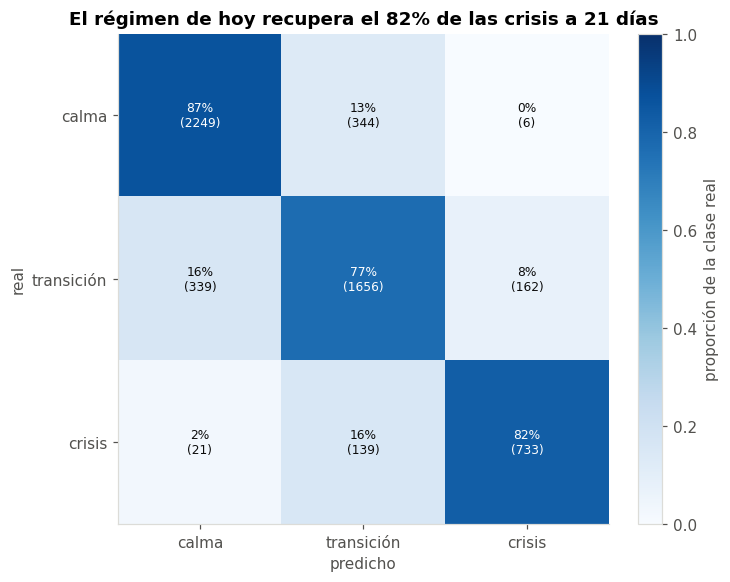

In [8]:
tramos = [("train", slice(None, particiones.train_hasta)),
          ("validación", slice(particiones.train_hasta, particiones.val_hasta)),
          ("test", slice(particiones.val_hasta, None))]
reparto = pd.DataFrame(
    {n: regimenes.distribucion(regimen_futuro.loc[t], etiquetador.n_estados)["porcentaje"]
     for n, t in tramos}).T.set_axis(nombres, axis=1)

# La verdad es la etiqueta futura y la predicción el régimen de hoy, no al revés:
# transponer no cambia el acierto pero convierte el recall en precisión.
hay = regimen_futuro.notna()
y_reg = regimen_futuro[hay].astype(int)
base = evaluacion.linea_base_persistencia(y_reg, regimen[hay], etiquetador.n_estados)
persistencia = evaluacion.matriz_confusion(y_reg, regimen[hay], etiquetador.n_estados)

print("Reparto de la etiqueta a", config.ventanas().horizonte, "días, en % de ventanas:")
print(reparto.round(1).to_string())
print("La persistencia acierta el", round(100 * base["accuracy"], 1),
      "% · recall de crisis:", round(100 * base["recall_crisis"], 1),
      "% · precisión de crisis:", round(100 * base["precision_crisis"], 1), "%")

fig, eje = plt.subplots(figsize=(6.6, 5.4))
viz.confusion(persistencia, "El régimen de hoy recupera el {:.0%} de las crisis a 21 días".format(base["recall_crisis"]), eje=eje)
viz.guardar(fig, "linea_base_persistencia")

## Qué se lleva el resto del proyecto

- **La etiqueta.** `regimen_futuro`, con la crisis en torno al 16 % de las
  ventanas. Es la clase minoritaria que justifica todo el taller.
- **El etiquetador entero**, no solo las etiquetas: el cuaderno 14 tiene que poder
  etiquetar series sintéticas con el mismo criterio exacto.
- **La línea base de persistencia**: accuracy 82,1 % y recall de crisis 82,1 %
  sobre la **muestra completa**, dominada por el tramo de entrenamiento. Esa no
  es la barra del cuaderno 03, que mide sobre test: allí la misma persistencia
  Viterbi baja a 0,805 de accuracy, 0,790 de f1 macro y 0,800 de recall de
  crisis, y aún hay que descontarle lo que le regala el futuro. Ningún resultado
  del cuaderno 12 significa nada si no bate esa otra cifra.
- **Una advertencia sobre el catálogo.** `features_etiquetado` no es una lista
  cualquiera de canales: entra en un modelo gaussiano y por eso exige features
  estacionarias y sin masa puntual. Añadir una obliga a repetir el control.

## Salidas generadas

In [9]:
from pathlib import Path

src.DIR_METRICAS.mkdir(parents=True, exist_ok=True)

pd.concat([regimen, regimen_futuro, proba], axis=1).to_parquet(src.DIR_PROCESADO / "regimenes.parquet")
etiquetador.guardar(src.DIR_PROCESADO / "etiquetador_regimenes.pkl")
reparto.round(2).to_csv(src.DIR_METRICAS / "distribucion_regimenes.csv")
transicion.round(4).join(duracion.round(1).rename("duracion")).to_csv(src.DIR_METRICAS / "transicion_regimenes.csv")

salidas = [
    src.DIR_PROCESADO / "regimenes.parquet",
    src.DIR_PROCESADO / "etiquetador_regimenes.pkl",
    src.DIR_METRICAS / "distribucion_regimenes.csv",
    src.DIR_METRICAS / "transicion_regimenes.csv",
    src.DIR_FIGURAS / "control_etiquetado.png",
    src.DIR_FIGURAS / "linea_base_persistencia.png",
]

for ruta in salidas:
    ruta = Path(ruta)
    marca = "ok" if ruta.exists() else "--"
    print("[{}] {}".format(marca, ruta.relative_to(src.RAIZ)))

[ok] data\processed\regimenes.parquet
[ok] data\processed\etiquetador_regimenes.pkl
[ok] results\metricas\distribucion_regimenes.csv
[ok] results\metricas\transicion_regimenes.csv
[ok] results\figures\control_etiquetado.png
[ok] results\figures\linea_base_persistencia.png
